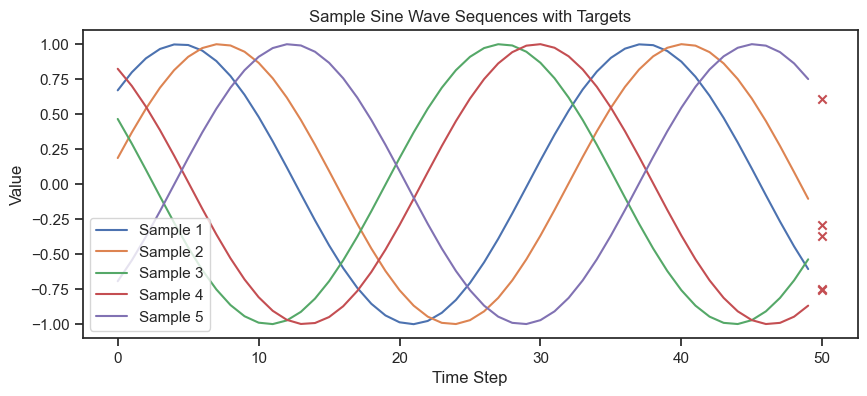

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name      | Type    | Params | Mode  | FLOPs
------------------------------------------------------
0 | rnn       | LSTM    | 40     | train | 0    
1 | fc        | Linear  | 3      | train | 0    
2 | criterion | MSELoss | 0      | train | 0    
------------------------------------------------------
43        Trainable params
0         Non-trainable params
43        Total params
0.000     Total estimated model params size (MB)
3         Modules in train mode
0         Modules in eval mode
0         Total Flops



--- Training RNN with Hidden Size: 2 ---


/Users/ddrous/miniconda3/envs/torchgpu/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/Users/ddrous/miniconda3/envs/torchgpu/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
`Trainer.fit` stopped: `max_epochs=500` reached.


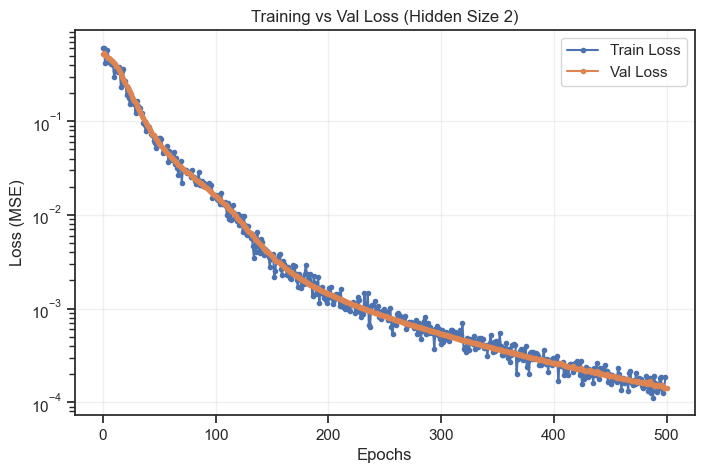

Final Val Loss: 0.00014


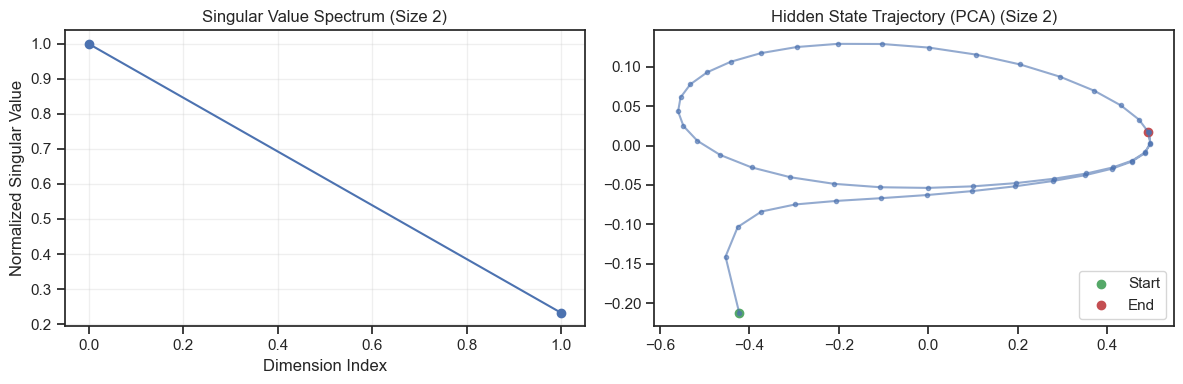

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name      | Type    | Params | Mode  | FLOPs
------------------------------------------------------
0 | rnn       | LSTM    | 112    | train | 0    
1 | fc        | Linear  | 5      | train | 0    
2 | criterion | MSELoss | 0      | train | 0    
------------------------------------------------------
117       Trainable params
0         Non-trainable params
117       Total params
0.000     Total estimated model params size (MB)
3         Modules in train mode
0         Modules in eval mode
0         Total Flops



--- Training RNN with Hidden Size: 4 ---


/Users/ddrous/miniconda3/envs/torchgpu/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/Users/ddrous/miniconda3/envs/torchgpu/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
`Trainer.fit` stopped: `max_epochs=500` reached.


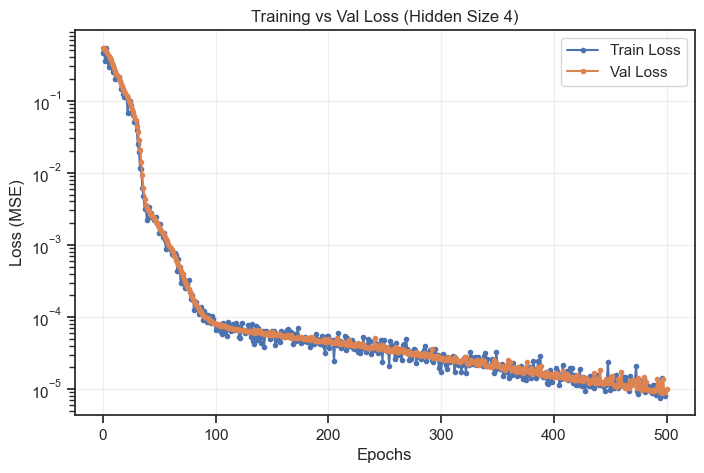

Final Val Loss: 0.00001


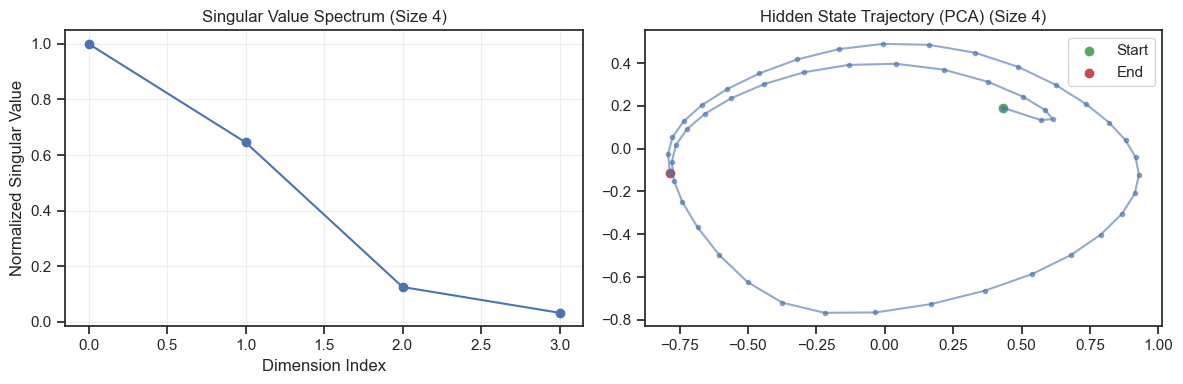

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name      | Type    | Params | Mode  | FLOPs
------------------------------------------------------
0 | rnn       | LSTM    | 4.5 K  | train | 0    
1 | fc        | Linear  | 33     | train | 0    
2 | criterion | MSELoss | 0      | train | 0    
------------------------------------------------------
4.5 K     Trainable params
0         Non-trainable params
4.5 K     Total params
0.018     Total estimated model params size (MB)
3         Modules in train mode
0         Modules in eval mode
0         Total Flops



--- Training RNN with Hidden Size: 32 ---


/Users/ddrous/miniconda3/envs/torchgpu/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/Users/ddrous/miniconda3/envs/torchgpu/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
`Trainer.fit` stopped: `max_epochs=500` reached.


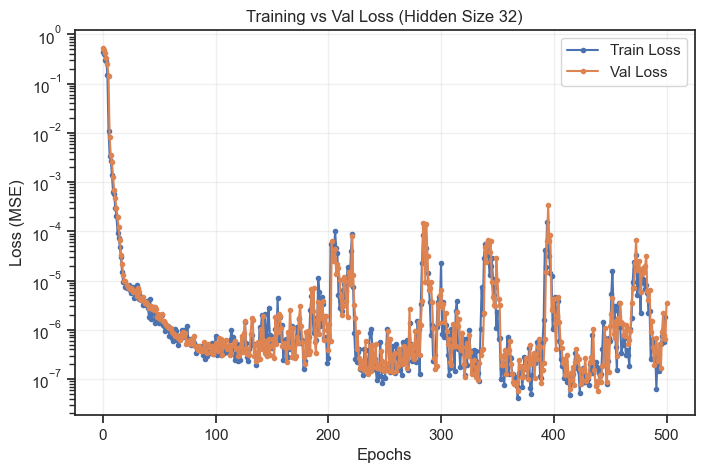

Final Val Loss: 0.00000


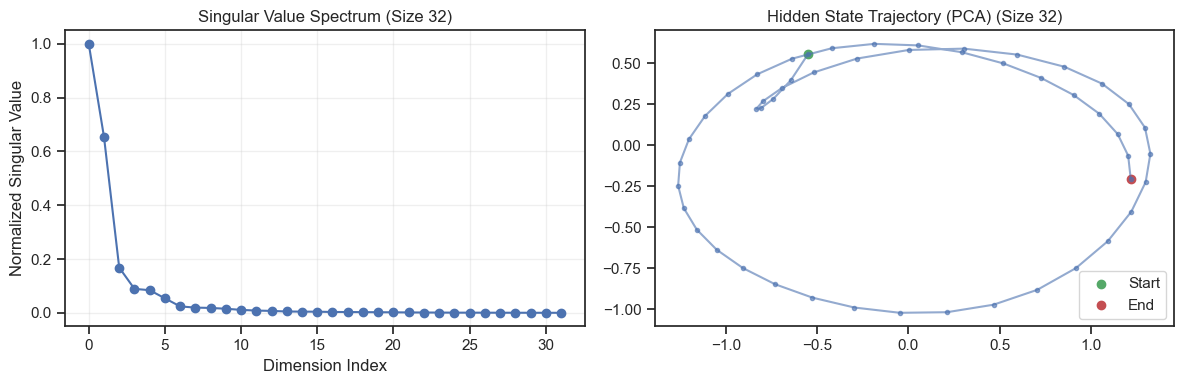

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name      | Type    | Params | Mode  | FLOPs
------------------------------------------------------
0 | rnn       | LSTM    | 67.1 K | train | 0    
1 | fc        | Linear  | 129    | train | 0    
2 | criterion | MSELoss | 0      | train | 0    
------------------------------------------------------
67.2 K    Trainable params
0         Non-trainable params
67.2 K    Total params
0.269     Total estimated model params size (MB)
3         Modules in train mode
0         Modules in eval mode
0         Total Flops



--- Training RNN with Hidden Size: 128 ---


/Users/ddrous/miniconda3/envs/torchgpu/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/Users/ddrous/miniconda3/envs/torchgpu/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
`Trainer.fit` stopped: `max_epochs=500` reached.


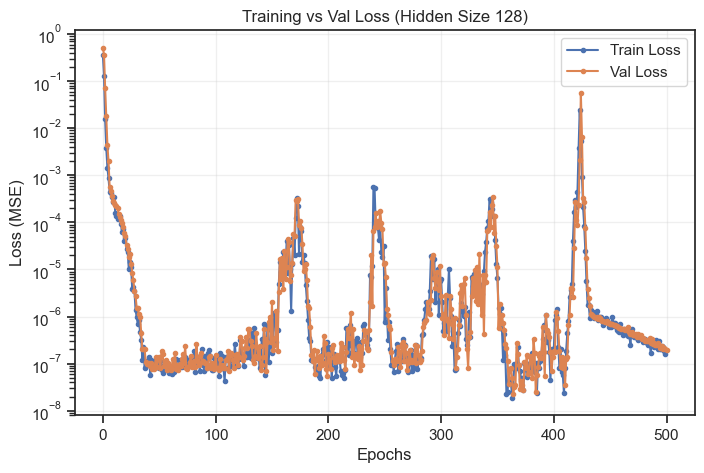

Final Val Loss: 0.00000


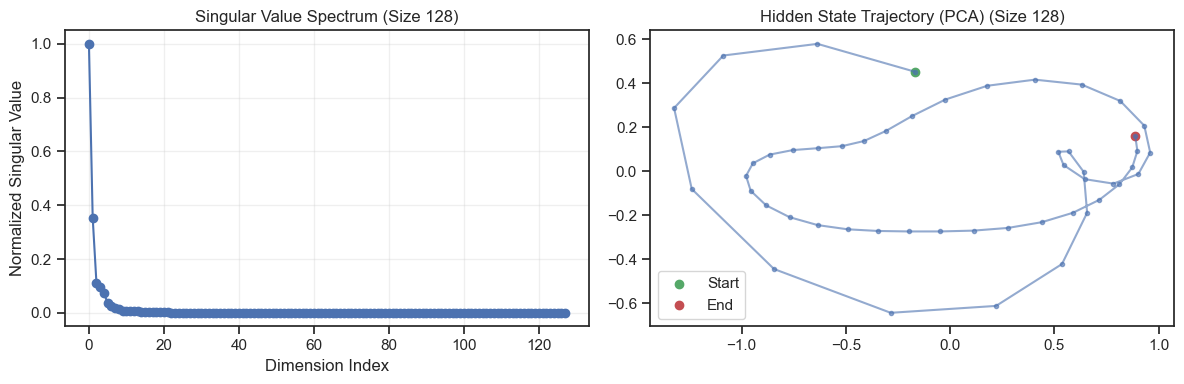

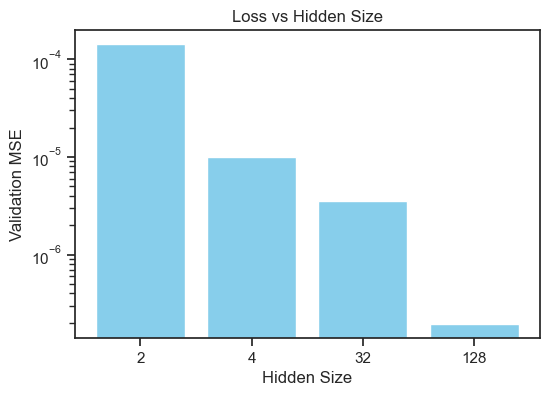

In [ ]:
import pytorch_lightning as pl
from data import SineWaveDataModule
from models import RNNRegressor
from analysis import analyze_hidden_states, plot_loss_curves, LossHistory
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='ticks')

def run_experiment():
    # Setup Data
    dm = SineWaveDataModule(seq_len=50, batch_size=64)
    dm.setup()
    

    ## PLot a few data samples
    x_sample, y_sample = next(iter(dm.train_dataloader()))
    plt.figure(figsize=(10, 4))
    for i in range(5):
        plt.plot(x_sample[i].squeeze().numpy(), label=f'Sample {i+1}')
        plt.scatter(len(x_sample[i]), y_sample[i].item(), c='r', marker='x') # Target point
    plt.title('Sample Sine Wave Sequences with Targets')
    plt.xlabel('Time Step')
    plt.ylabel('Value')
    plt.legend()
    plt.show()

    # Sizes to compare: 1 (Too small), 4 (Likely too small), 32 (Sufficient)
    hidden_sizes = [2, 4, 32, 128] 
    # hidden_sizes = []
    
    results = {}

    for h_size in hidden_sizes:
        print(f"\n--- Training RNN with Hidden Size: {h_size} ---")
        
        model = RNNRegressor(rnn_type='LSTM', input_size=1, hidden_size=h_size, lr=1e-3)
        
        # Train
        history = LossHistory()
        
        trainer = pl.Trainer(
            max_epochs=500, 
            callbacks=[history], # <--- Add here
            enable_progress_bar=False, 
            logger=False, 
            enable_checkpointing=False
        )
        trainer.fit(model, dm)
        
        plot_loss_curves(history, title=f"Training vs Val Loss (Hidden Size {h_size})")

        # Store final val loss
        val_loss = trainer.validate(model, dm, verbose=False)[0]['val_loss']
        results[h_size] = val_loss
        
        # Visualize
        print(f"Final Val Loss: {val_loss:.5f}")
        analyze_hidden_states(model, dm.val_dataloader(), title_suffix=f"(Size {h_size})")

    # Final Loss Comparison
    plt.figure(figsize=(6, 4))
    plt.bar([str(k) for k in results.keys()], results.values(), color='skyblue')
    plt.xlabel('Hidden Size'); plt.ylabel('Validation MSE')
    plt.yscale('log')
    plt.title('Loss vs Hidden Size')
    plt.show()

if __name__ == "__main__":
    run_experiment()